[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/pablolob/calc_dif_equations_LAB/blob/main/03_Ley_de_Murray.ipynb)

# 🩸 LAB 3: Ley de Murray — Por Qué los Vasos Sanguíneos Se Ramifican Así

Los pulmones, el sistema vascular y un árbol tienen algo en común: sus ramificaciones no son aleatorias. Cecil Murray (1926) demostró que los vasos sanguíneos se bifurcan exactamente en el ángulo que **minimiza el trabajo que realiza el corazón** — y ese ángulo se puede calcular con Cálculo Diferencial de una variable.

**El Caso**: Una arteria principal de radio $r_0$ debe alimentar un tejido en el punto $P = (4, 3)$ (coordenadas en mm). La arteria recorre el eje horizontal y puede bifurcarse en cualquier punto $x$.

La resistencia al flujo de un vaso de radio $r$ y longitud $L$ sigue la **Ley de Poiseuille**:
$$\text{Resistencia} \propto \frac{L}{r^4}$$

¿En qué punto $x$ debe bifurcarse la arteria para minimizar el coste metabólico total?

---

In [ ]:
# !!! ESTA CELDA ES SOLO DE CONFIGURACIÓN.
# Este bloque contiene código auxiliar; ejecútalo para poder visualizar los resultados más adelante.
import numpy as np
import matplotlib.pyplot as plt

def dibujar_ramificacion(r0, r1, d, h, x_star, W_func=None):
    """Geometría de la bifurcación + función de coste metabólico."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    # --- Panel izquierdo: geometría vascular ---
    lw_main   = r0 * 10
    lw_branch = r1 * 10
    ax1.plot([0, x_star], [0,  0], color='crimson',   lw=lw_main,   solid_capstyle='round',
             label=f'Tronco principal  (r₀ = {r0:.2f} mm)')
    ax1.plot([x_star, d], [0,  h], color='steelblue', lw=lw_branch, solid_capstyle='round',
             label=f'Ramas  (r₁ = {r1:.2f} mm)')
    ax1.plot([x_star, d], [0, -h], color='steelblue', lw=lw_branch, solid_capstyle='round')
    ax1.scatter(x_star, 0, color='limegreen', s=150, zorder=5,
                label=f'Bifurcación óptima  x* = {x_star:.2f} mm')
    ax1.scatter([d, d], [h, -h], color='darkorange', s=100, zorder=5, marker='*',
                label='Tejido objetivo')
    theta_deg = np.degrees(np.arctan2(h, d - x_star))
    ax1.annotate(f'θ = {theta_deg:.1f}°', xy=(x_star + 0.2, 0.2), fontsize=12)
    ax1.set_xlim(-0.5, d + 0.6); ax1.set_ylim(-h - 0.6, h + 0.6)
    ax1.set_aspect('equal')
    ax1.set_xlabel('x (mm)'); ax1.set_ylabel('y (mm)')
    ax1.set_title('Geometría de Bifurcación Óptima')
    ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)

    # --- Panel derecho: función de coste ---
    if W_func is not None:
        xs = np.linspace(0.05, d - 0.05, 400)
        Ws = [W_func(x) for x in xs]
        ax2.plot(xs, Ws, color='mediumpurple', lw=2.5, label='W(x)')
        ax2.scatter(x_star, W_func(x_star), color='limegreen', s=120, zorder=5,
                    label=f'Mínimo: x* = {x_star:.2f}')
        ax2.axvline(x_star, color='limegreen', lw=1.2, linestyle='--', alpha=0.6)
        ax2.set_xlabel('Posición de bifurcación x (mm)')
        ax2.set_ylabel('Coste metabólico W(x)')
        ax2.set_title('Función de Coste W(x)')
        ax2.legend(); ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## 🔬 El Coste Metabólico de la Circulación

Imagina la arteria dividida en dos tramos:

- **Tronco principal**: desde el origen hasta el punto de bifurcación $x$. Longitud $= x$, radio $r_0$.
- **Rama**: desde el punto de bifurcación hasta el tejido $P = (d, h)$. Longitud $= \sqrt{(d-x)^2 + h^2}$, radio $r_1$.

Sumando costes de Poiseuille, el trabajo total del corazón es:

$$W(x) = \frac{x}{r_0^4} + \frac{\sqrt{(d-x)^2 + h^2}}{r_1^4}$$

Para bifurcaciones simétricas la **Ley de Murray** establece que el radio óptimo de la rama es:

$$r_1 = \frac{r_0}{2^{1/3}}$$

<details>
<summary><b>¿De dónde viene la Ley de Murray? Haz clic para ver la deducción</b></summary>

Un vaso de radio $r$, longitud $L$ y caudal $Q$ tiene dos costes:

$$W(r) = \underbrace{\frac{8\eta}{\pi} \cdot \frac{Q^2 L}{r^4}}_{\text{trabajo del corazón (Poiseuille)}} + \underbrace{k_m \cdot \pi r^2 L}_{\text{coste metabólico del tejido vascular}}$$

Minimizamos respecto a $r$ (con $Q$ fijo):

$$\frac{dW}{dr} = -\frac{32\eta Q^2 L}{\pi\, r^5} + 2 k_m \pi r L = 0$$

Despejando:

$$Q^2 \propto r^6 \quad\Longrightarrow\quad Q \propto r^3$$

En una bifurcación, la conservación del flujo exige $Q_0 = Q_1 + Q_2$. Sustituyendo $Q \propto r^3$:

$$\boxed{r_0^3 = r_1^3 + r_2^3}$$

Para una bifurcación **simétrica** ($r_1 = r_2$): $\;r_1^3 = r_0^3 / 2\;$, luego $\;r_1 = r_0 / 2^{1/3}$.

</details>

---

### 🛠️ ¡TU TURNO!

Dado el coste $W(x)$ de arriba, tu tarea es:

1. **Implementar `W(x)`** en Python.
2. **Calcular $\dfrac{dW}{dx}$** analíticamente.
3. **Implementar `dW_dx(x)`** 
4. **verificar** que se anula en el mínimo que encuentra el algoritmo. 



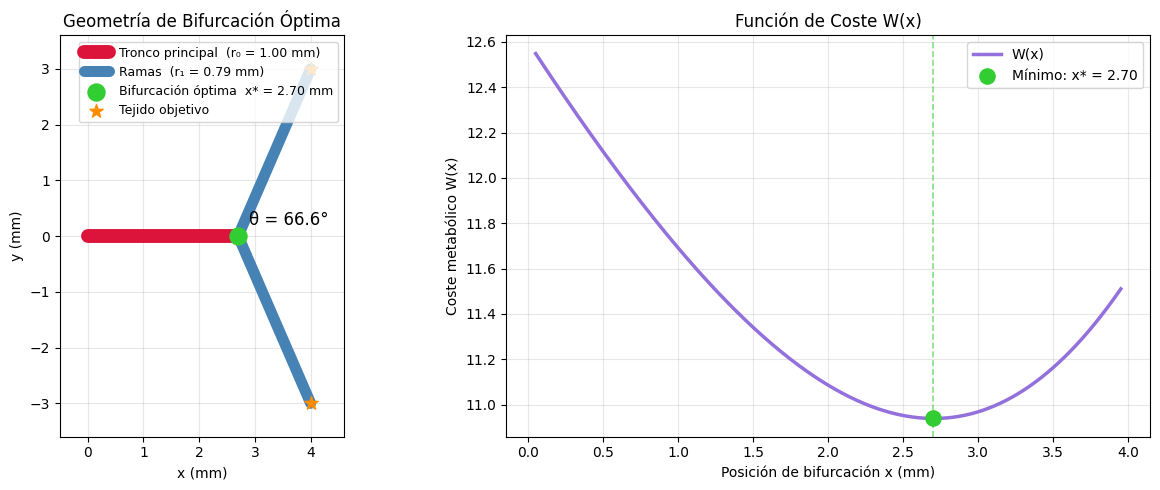

In [ ]:
r0 = 1.0             # Radio arteria principal (mm)
r1 = r0 / 2**(1/3)  # Ley de Murray: bifurcación simétrica
d  = 4.0             # Distancia horizontal al tejido (mm)
h  = 3.0             # Distancia perpendicular al tejido (mm)

def W(x):
    None    # <--- ¡Tu turno! Función del trabajo total
def dW_dx(x):
    None    # <--- ¡Tu turno! Derivada del trabajo total respecto a x

# El algoritmo busca el mínimo numéricamente para dibujarlo
xs = np.linspace(0.05, d - 0.05, 500)
x_star = xs[np.argmin([W(x) for x in xs])]

dibujar_ramificacion(r0, r1, d, h, x_star, W)

<details>
<summary><b>¿Atascado? Haz clic aquí para ver la Solución</b></summary>

```python
def W(x):
    return x / r0**4 + np.sqrt((d - x)**2 + h**2) / r1**4

def dW_dx(x):
    return 1 / r0**4 - (d - x) / (r1**4 * np.sqrt((d - x)**2 + h**2))
```
</details>

### El Ángulo de Murray

Fíjate en la condición del mínimo: $\dfrac{dW}{dx}(x^*) = 0$ implica:

$$\frac{1}{r_0^4} = \frac{d - x^*}{r_1^4\,\sqrt{(d-x^*)^2 + h^2}}$$

El término de la derecha es exactamente $\dfrac{\cos\theta}{r_1^4}$, donde $\theta$ es el ángulo de bifurcación respecto al eje del tronco. Por tanto:

$$\boxed{\cos\theta^* = \left(\frac{r_1}{r_0}\right)^4 = 2^{-4/3} \approx 0.397 \quad\Rightarrow\quad \theta^* \approx 66.6°}$$

**El resultado sorprendente**: el ángulo óptimo solo depende de la *relación de radios*, no de las distancias $d$ ni $h$. Las mediciones experimentales en capilares, bronquiolos y venas coronarias confirman esta predicción con notable precisión.

In [16]:
# Comprobación: ángulo teórico vs. ángulo observado
theta_murray  = np.degrees(np.arccos((r1 / r0)**4))
theta_grafico = np.degrees(np.arctan2(h, d - x_star))

print(f"Ángulo de Murray teórico : θ* = {theta_murray:.2f}°")
print(f"Ángulo observado en gráfico: {theta_grafico:.2f}°")
print(f"dW/dx en x* = {dW_dx(x_star):.6f}  (debería ser ≈ 0)")

Ángulo de Murray teórico : θ* = 66.62°
Ángulo observado en gráfico: 66.56°
dW/dx en x* = -0.002233  (debería ser ≈ 0)


### 🔍 Experimenta y Reflexiona

- **Cambia el tejido objetivo**: prueba `d=6, h=1` o `d=2, h=4`. ¿Cambia el ángulo de bifurcación? ¿Por qué?
- **Cambia `r0`**: prueba `r0=0.5` o `r0=2.0`. ¿Cómo afecta a `r1` y al ángulo?


### Visualización de multiples bifurcaciones

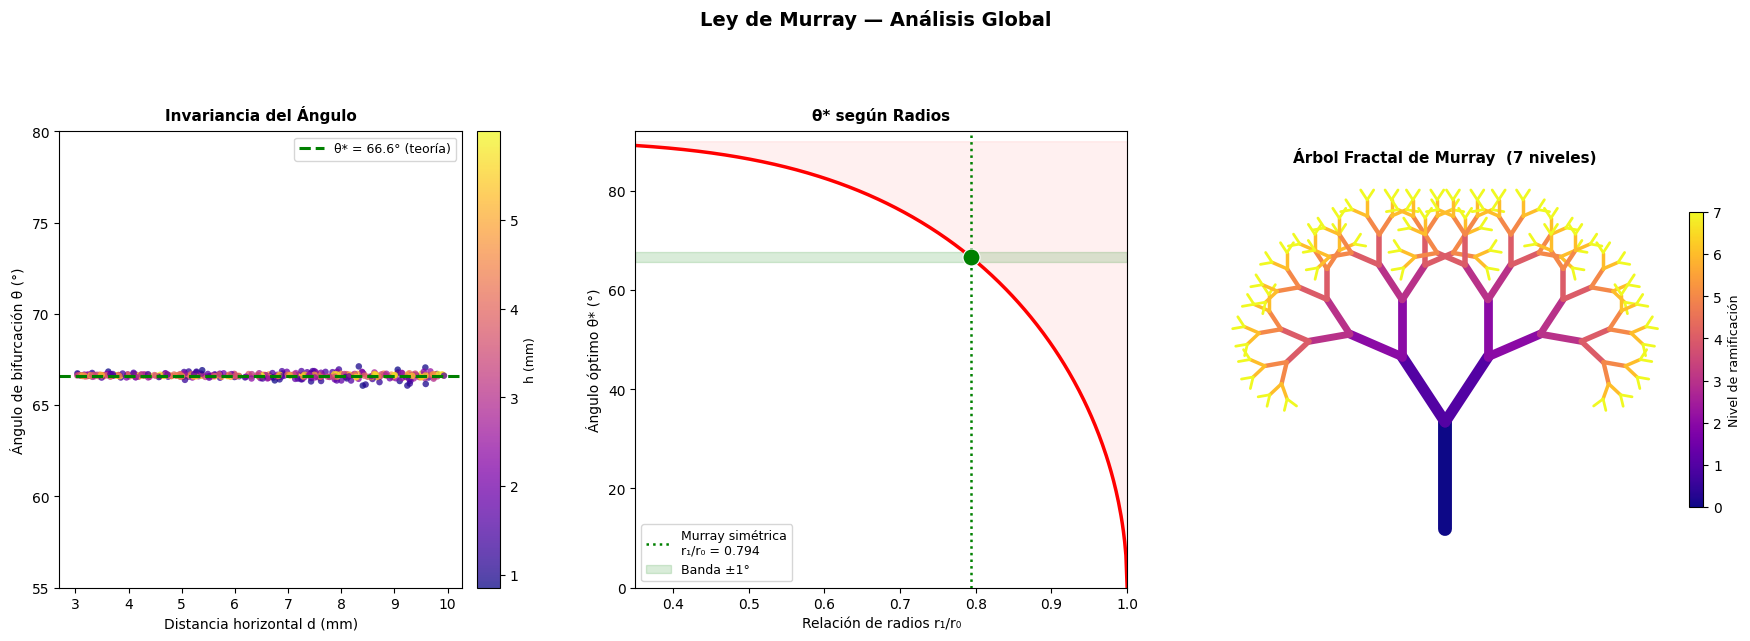

In [18]:

# ──────────────────────────────────────────────────────────────────────────────
# Visualización global de la Ley de Murray
# Requiere haber ejecutado las celdas anteriores (r0, r1, d, h, x_star definidos)
# ──────────────────────────────────────────────────────────────────────────────
from matplotlib.collections import LineCollection

fig = plt.figure(figsize=(18, 6.5))

# ── Panel 1: invariancia del ángulo θ* ───────────────────────────────────────
ax1 = fig.add_subplot(1, 3, 1)

np.random.seed(42)
d_rnd = np.random.uniform(3, 10, 400)
h_rnd = np.random.uniform(0.8,  6, 400)
theta_num = np.empty(400)

for k in range(400):
    dk, hk   = d_rnd[k], h_rnd[k]
    xs_k     = np.linspace(0.05, dk - 0.05, 400)
    costs    = xs_k / r0**4 + np.sqrt((dk - xs_k)**2 + hk**2) / r1**4
    x_k      = xs_k[np.argmin(costs)]
    theta_num[k] = np.degrees(np.arctan2(hk, dk - x_k))

theta_teo = np.degrees(np.arccos((r1 / r0)**4))
sc = ax1.scatter(d_rnd, theta_num, c=h_rnd, cmap='plasma',
                 s=22, alpha=0.75, edgecolors='none')
cb = plt.colorbar(sc, ax=ax1, pad=0.03)
cb.set_label('h (mm)', fontsize=9)
ax1.axhline(theta_teo, color='green', lw=2.2, linestyle='--',
            label=f'θ* = {theta_teo:.1f}° (teoría)')
ax1.set_xlabel('Distancia horizontal d (mm)')
ax1.set_ylabel('Ángulo de bifurcación θ (°)')
ax1.set_title('Invariancia del Ángulo', fontsize=11, fontweight='bold', pad=8)
ax1.legend(fontsize=9)
ax1.set_ylim(55, 80)

# ── Panel 2: θ* vs relación de radios ────────────────────────────────────────
ax2 = fig.add_subplot(1, 3, 2)

r_ratio = np.linspace(0.35, 1.0, 400)
theta_vs_ratio = np.degrees(np.arccos(r_ratio**4))

ax2.plot(r_ratio, theta_vs_ratio, color='red', lw=2.5)
ax2.axvline(r1 / r0, color='green', lw=1.8, linestyle=':',
            label=f'Murray simétrica\nr₁/r₀ = {r1/r0:.3f}')
ax2.scatter([r1 / r0], [theta_teo], color='green', s=150,
            zorder=5, edgecolors='white', lw=0.8)
ax2.fill_between(r_ratio, theta_vs_ratio, 90, alpha=0.06, color='red')
ax2.axhspan(theta_teo - 1, theta_teo + 1, alpha=0.15, color='green', label='Banda ±1°')
ax2.set_xlabel('Relación de radios r₁/r₀')
ax2.set_ylabel('Ángulo óptimo θ* (°)')
ax2.set_title('θ* según Radios', fontsize=11, fontweight='bold', pad=8)
ax2.legend(fontsize=9)
ax2.set_xlim(0.35, 1.0); ax2.set_ylim(0, 92)

# ── Panel 3: árbol fractal de Murray ─────────────────────────────────────────
ax3 = fig.add_subplot(1, 3, 3)
cmap_tree = plt.cm.plasma

def _murray_tree(levels=7, r0_t=1.0):
    theta_m = np.arccos((1 / 2**(1/3))**4)
    segs, cols, wids = [], [], []

    def _recurse(x0, y0, ang, length, radius, lv):
        if lv > levels or radius < 0.005:
            return
        x1 = x0 + length * np.cos(ang)
        y1 = y0 + length * np.sin(ang)
        segs.append([(x0, y0), (x1, y1)])
        cols.append(cmap_tree(lv / levels))
        wids.append(max(radius * 10, 0.4))
        r_new = radius / 2**(1/3)
        l_new = length * 0.73
        _recurse(x1, y1, ang + theta_m * 0.5, l_new, r_new, lv + 1)
        _recurse(x1, y1, ang - theta_m * 0.5, l_new, r_new, lv + 1)

    _recurse(0, -3.0, np.pi / 2, 3.2, r0_t, 0)
    return segs, cols, wids

segs, cols, wids = _murray_tree(levels=7)
lc = LineCollection(segs, colors=cols, linewidths=wids, capstyle='round')
ax3.add_collection(lc)
ax3.autoscale()
ax3.set_aspect('equal')
ax3.axis('off')
ax3.set_title('Árbol Fractal de Murray  (7 niveles)',
              fontsize=11, fontweight='bold', pad=8)

sm = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(0, 7))
sm.set_array([])
cb3 = plt.colorbar(sm, ax=ax3, fraction=0.03, pad=0.02)
cb3.set_label('Nivel de ramificación', fontsize=9)

fig.suptitle('Ley de Murray — Análisis Global', fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout(pad=2.5)
plt.show()


---

## 📚 Referencias

**Murray, C.D. (1926).** *The Physiological Principle of Minimum Work.* Proceedings of the National Academy of Sciences, 12(3), 207–214.  
[→ DOI: 10.1073/pnas.12.3.207](https://doi.org/10.1073/pnas.12.3.207)

**Sherman, T.F. (1981).** *On connecting large vessels to small: the meaning of Murray's law.* Journal of General Physiology, 78(4), 431–453.  
[→ DOI: 10.1085/jgp.78.4.431](https://doi.org/10.1085/jgp.78.4.431)

**Zamir, M. (1977).** *Nonsymmetrical bifurcations in arterial branching.* Journal of General Physiology, 72(6), 837–845.  
[→ DOI: 10.1085/jgp.72.6.837](https://doi.org/10.1085/jgp.72.6.837)

**Rall, W. (1959).** *Branching dendritic trees and motoneuron membrane resistivity.* Experimental Neurology, 1(5), 491–527.  
[→ DOI: 10.1016/0014-4886(59)90046-9](https://doi.org/10.1016/0014-4886(59)90046-9)

---

## Mis Respuestas

**Pregunta 1.**

*Escribe aquí tu respuesta...*

---

**Pregunta 2.**

*Escribe aquí tu respuesta...*

---
